In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import files
data=files.upload()

Saving airport_cargo_regression_practice (1).xlsx to airport_cargo_regression_practice (1) (1).xlsx


In [6]:
df=pd.read_excel('airport_cargo_regression_practice (1) (1).xlsx')

`processing`

`dirty data`

- null value in weight
- comma in weight
- underscore in desination zone

In [7]:
df.head()

,Shipment_ID,Weight_KG,Priority_Level,Destination_Zone,Warehouse_Distance_Meters,Handling_Agents,Processing_Time_Mins
0,1000,998.9,Low,Zone_C,137.7,4,63.0
1,1001,2381.7,Medium,Zone_B,754.9,3,207.3
2,1002,1856.8,High,Zone_A,520.8,5,139.1
3,1003,1536.8,Medium,Zone_D,301.2,1,115.3
4,1004,474.4,Low,Zone_C,154.5,5,36.9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                250 non-null    int64  
 1   Weight_KG                  238 non-null    float64
 2   Priority_Level             250 non-null    object 
 3   Destination_Zone           250 non-null    object 
 4   Warehouse_Distance_Meters  250 non-null    float64
 5   Handling_Agents            250 non-null    int64  
 6   Processing_Time_Mins       250 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 13.8+ KB


In [9]:
df.describe()

,Shipment_ID,Weight_KG,Warehouse_Distance_Meters,Handling_Agents,Processing_Time_Mins
count,250.000000,238.000000,250.000000,250.000000,250.000000
mean,1124.500000,1272.159664,407.795200,3.004000,110.386400
std,72.312977,711.952137,214.596337,1.443718,46.344382
min,1000.000000,112.100000,53.500000,1.000000,15.000000
25%,1062.250000,647.525000,217.000000,2.000000,74.425000
50%,1124.500000,1299.850000,400.300000,3.000000,116.750000
75%,1186.750000,1907.875000,589.825000,4.000000,144.600000
max,1249.000000,2468.500000,797.700000,5.000000,207.300000


In [10]:
df.isnull().sum()

,0
Shipment_ID,0
Weight_KG,12
Priority_Level,0
Destination_Zone,0
Warehouse_Distance_Meters,0
Handling_Agents,0
Processing_Time_Mins,0


In [11]:
df.duplicated().sum()

np.int64(0)

filling missing value in weight col


In [12]:
weight_median=df['Weight_KG'].median()
df['Weight_KG']=df['Weight_KG'].fillna(weight_median)

df['Weight_KG'].isnull().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
Shipment_ID,0
Weight_KG,0
Priority_Level,0
Destination_Zone,0
Warehouse_Distance_Meters,0
Handling_Agents,0
Processing_Time_Mins,0


removing comma from weight

In [14]:
df['Weight_KG'] = df['Weight_KG'].astype(str).str.replace(',', '').astype(float)
df.describe()

,Shipment_ID,Weight_KG,Warehouse_Distance_Meters,Handling_Agents,Processing_Time_Mins
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,1124.500000,1273.488800,407.795200,3.004000,110.386400
std,72.312977,694.610158,214.596337,1.443718,46.344382
min,1000.000000,112.100000,53.500000,1.000000,15.000000
25%,1062.250000,671.450000,217.000000,2.000000,74.425000
50%,1124.500000,1299.850000,400.300000,3.000000,116.750000
75%,1186.750000,1850.725000,589.825000,4.000000,144.600000
max,1249.000000,2468.500000,797.700000,5.000000,207.300000


# `eda`

`*numerical col*`
- Processing_Time_Mins
- Weight_KG
- Warehouse_Distance_Meters
- Handling_Agents

`categorical `
- priority level
- destination zone

<Axes: xlabel='Weight_KG'>

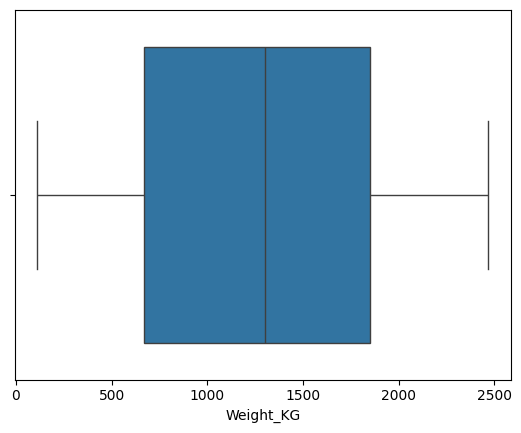

In [ ]:
sns.boxplot(data=df,x='Weight_KG')

<Axes: xlabel='Processing_Time_Mins'>

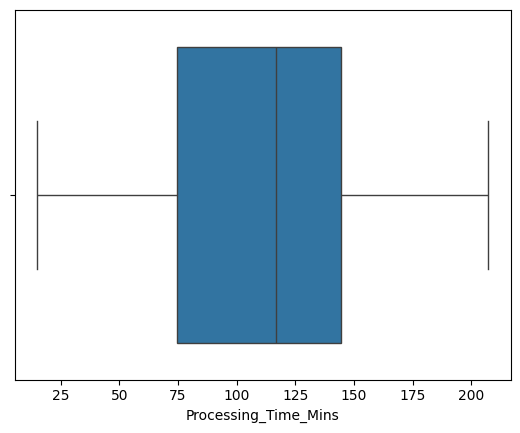

In [ ]:
sns.boxplot(data=df,x='Processing_Time_Mins')

<Axes: xlabel='Warehouse_Distance_Meters'>

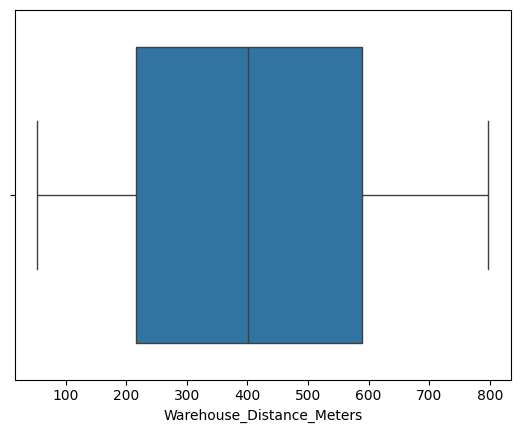

In [ ]:
sns.boxplot(data=df,x='Warehouse_Distance_Meters')

<Axes: xlabel='Handling_Agents'>

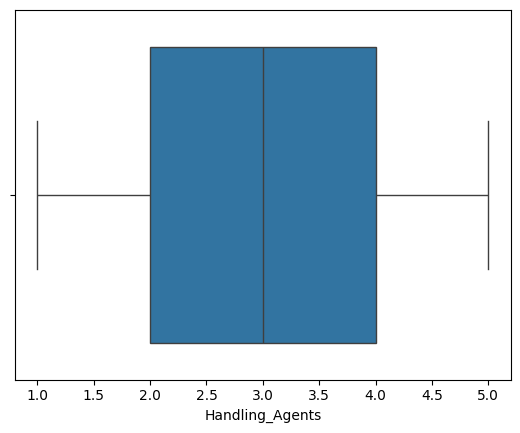

In [ ]:
sns.boxplot(data=df,x='Handling_Agents')

<Axes: xlabel='Processing_Time_Mins', ylabel='Density'>

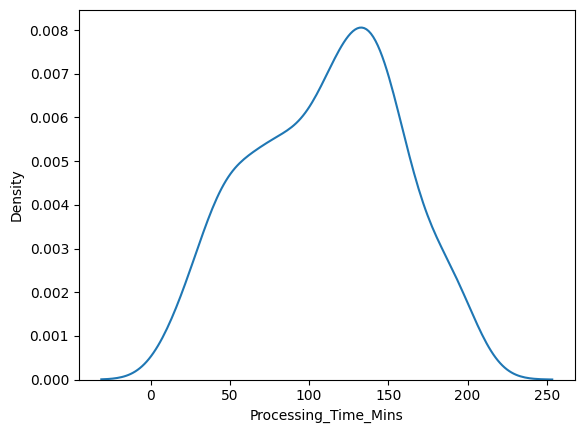

In [ ]:
sns.kdeplot(data=df,x='Processing_Time_Mins')

<Axes: xlabel='Warehouse_Distance_Meters', ylabel='Density'>

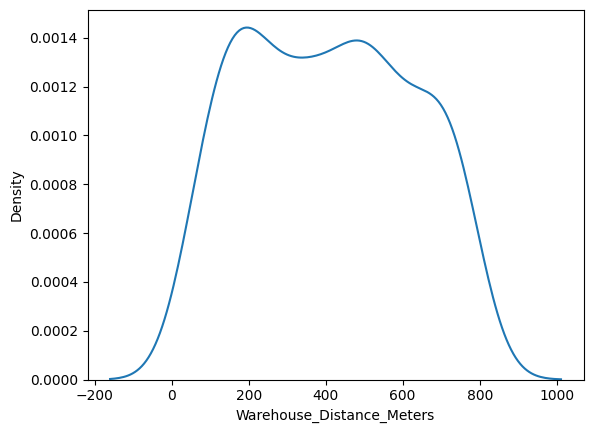

In [ ]:
sns.kdeplot(data=df , x='Warehouse_Distance_Meters')

<Axes: xlabel='Handling_Agents', ylabel='Density'>

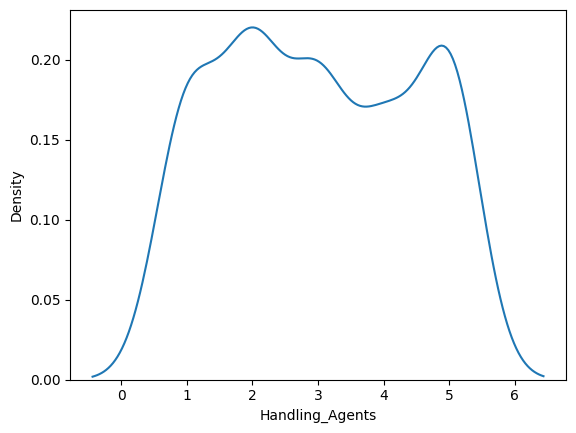

In [ ]:
sns.kdeplot(data=df,x='Handling_Agents')

<Axes: xlabel='Weight_KG', ylabel='Density'>

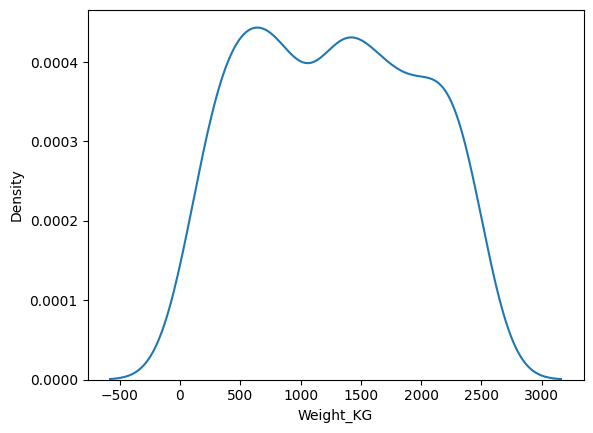

In [ ]:
sns.kdeplot(data=df,x='Weight_KG')

In [ ]:
df['Weight_KG'].skew()


np.float64(0.05085692170085716)

In [ ]:
df['Handling_Agents'].skew()

np.float64(0.057544241304548036)

In [ ]:
df['Warehouse_Distance_Meters'].skew()

np.float64(0.07152165053256086)

In [ ]:
df['Processing_Time_Mins'].skew()

np.float64(-0.13171017145127673)

`*numerical col*`
- Processing_Time_Mins
- Weight_KG
- Warehouse_Distance_Meters
- Handling_Agents

`categorical `
- priority level
- destination zone

`bivariate analysis`

- numerical-----numerical

<Axes: xlabel='Processing_Time_Mins', ylabel='Weight_KG'>

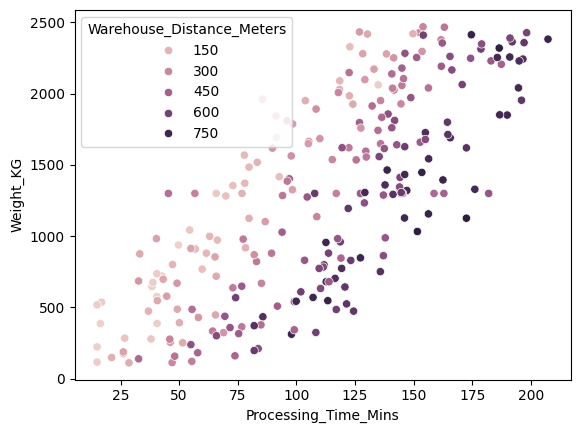

In [ ]:
sns.scatterplot(data=df,x='Processing_Time_Mins',y='Weight_KG',hue='Warehouse_Distance_Meters')

graph we can assume that some packages despite of being heavy have less processing time due to short distance

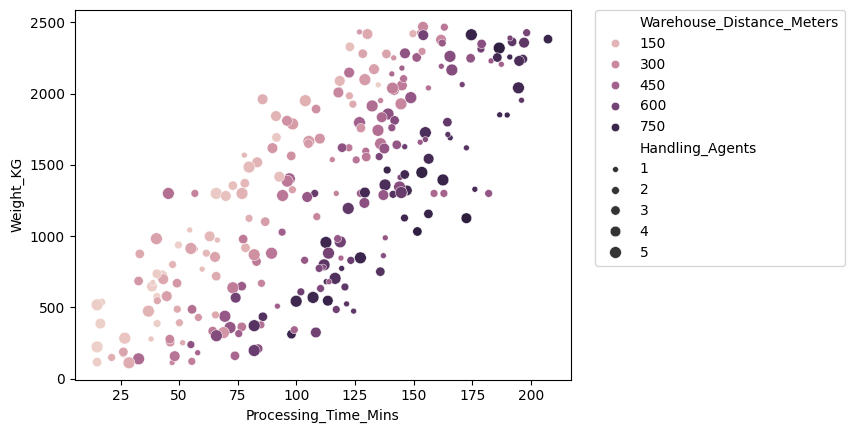

In [ ]:
sns.scatterplot(data=df,x='Processing_Time_Mins',y='Weight_KG',hue='Warehouse_Distance_Meters',size='Handling_Agents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

from the graph i can assume that despit of being smaller weight distance it took 5 agent and less processing time

`numerical--------categorical`

<Axes: xlabel='Processing_Time_Mins', ylabel='Priority_Level'>

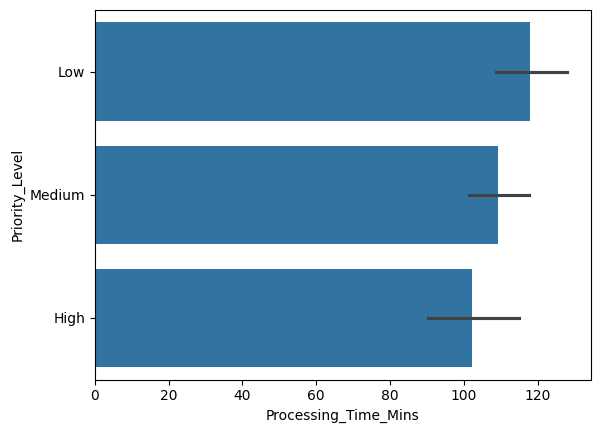

In [ ]:
sns.barplot(data=df,x='Processing_Time_Mins',y='Priority_Level')

Processing Time vs. Priority: Heavily related. High Priority = Less Processing Time. The priority pipeline works exactly as intended.

<Axes: xlabel='Weight_KG', ylabel='Priority_Level'>

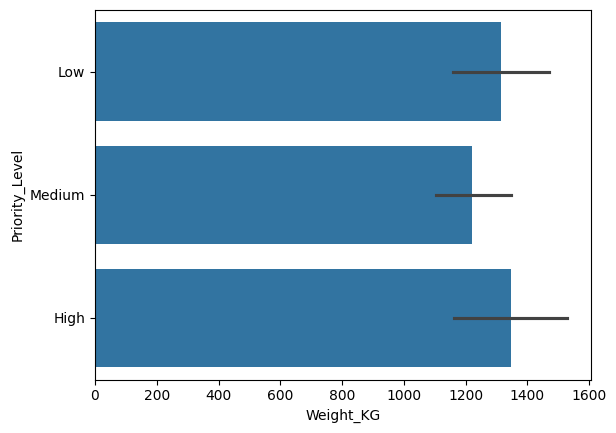

In [ ]:
sns.barplot(data=df,x='Weight_KG',y='Priority_Level')

Weight vs. Priority: Not related. Heavy and light packages are distributed evenly across all priority levels.

<Axes: xlabel='Warehouse_Distance_Meters', ylabel='Priority_Level'>

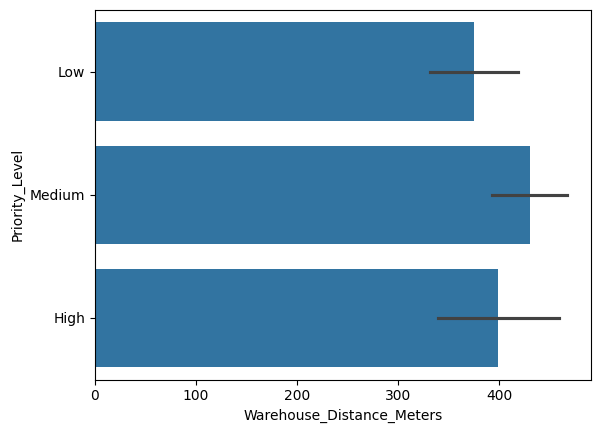

In [ ]:
sns.barplot(data=df,x='Warehouse_Distance_Meters',y='Priority_Level')

Distance vs. Priority: Doesn't matter. The physical distance a package has to travel is independent of its priority tag.

<Axes: xlabel='Handling_Agents', ylabel='Priority_Level'>

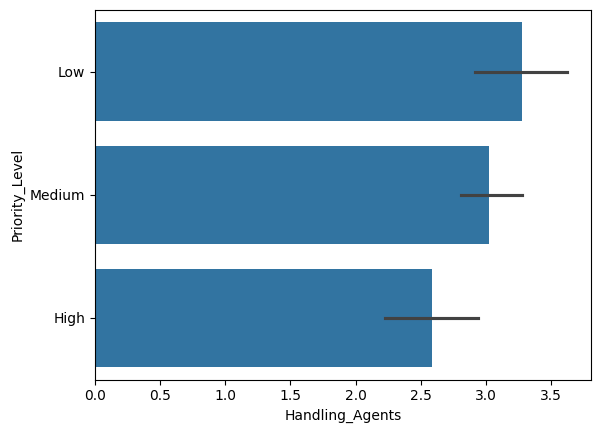

In [ ]:
sns.barplot(data=df,x='Handling_Agents',y='Priority_Level')

Agents vs. Priority: Inverse relationship. Surprisingly, fewer agents are assigned to High Priority tasks, meaning their speed comes from operational efficiency or other factors rather than sheer workforce size.

In [15]:
pd.crosstab(df['Priority_Level'],df['Destination_Zone'])

Destination_Zone,Zone_A,Zone_B,Zone_C,Zone_D
Priority_Level,,,,
High,23,11,7,12
Low,31,12,18,11
Medium,54,28,16,27


`feature engineering `

In [16]:
df_copy=df.copy()

In [17]:
#ordinal encoding
prioriy={'Low':0,'Medium':1,'High':2}
df_copy['Priority_Level']=df_copy['Priority_Level'].map(prioriy)

In [18]:
#one hot encoding
df_copy=pd.get_dummies(df_copy , columns=['Destination_Zone'],drop_first=True,dtype=int)

In [19]:
df_copy.sample(3)

,Shipment_ID,Weight_KG,Priority_Level,Warehouse_Distance_Meters,Handling_Agents,Processing_Time_Mins,Destination_Zone_Zone_B,Destination_Zone_Zone_C,Destination_Zone_Zone_D
159,1159,1299.85,0,334.8,3,145.3,1,0,0
69,1069,2468.50,0,301.4,4,154.0,0,0,0
86,1086,1851.10,2,736.1,1,186.7,0,0,0


`standerize numerical col `

In [20]:
scaler=StandardScaler()
numericcol=['Handling_Agents', 'Warehouse_Distance_Meters', 'Weight_KG']
df_copy[numericcol]=scaler.fit_transform(df_copy[numericcol])

`drop shipment id col`

In [21]:

df_copyy=df_copy.copy()

In [22]:
df_copy=df_copyy.drop(columns=['Shipment_ID'])

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. SPLIT INTO FEATURES (X) AND TARGET (y)
# =====================================================================
# 'Processing_Time_Mins' is our target output, everything else is an input feature
X = df_copy.drop(columns=['Processing_Time_Mins'])
y = df_copy['Processing_Time_Mins']

# Split the data: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================================
# 2. INITIALIZE AND FIT THE MODEL
# =====================================================================
model = LinearRegression()
model.fit(X_train, y_train)

# =====================================================================
# 3. EVALUATE THE PERFORMANCE
# =====================================================================
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- Model Training Successful! ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R-squared (R²) Score: {r2:.4f} ({r2*100:.1f}% of variance explained)")

--- Model Training Successful! ---
Root Mean Squared Error (RMSE): 10.78 minutes
Root Mean Squared Error (RMSE): 10.78 minutes
R-squared (R²) Score: 0.9342 (93.4% of variance explained)


In [25]:

# Create a dataframe to store features and their corresponding weights
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': model.coef_
})

# Sort by the absolute impact so the most important features are at the top
coefficients['Absolute_Impact'] = coefficients['Coefficient (Weight)'].abs()
coefficients = coefficients.sort_values(by='Absolute_Impact', ascending=False).drop(columns=['Absolute_Impact'])

print(f"Base Intercept (Starting Time): {model.intercept_:.2f} minutes\n")
print("--- Feature Coefficients ---")
print(coefficients.to_string(index=False))

Base Intercept (Starting Time): 121.70 minutes

--- Feature Coefficients ---
                  Feature  Coefficient (Weight)
                Weight_KG             31.108106
Warehouse_Distance_Meters             26.880926
           Priority_Level            -12.208704
          Handling_Agents             -7.232951
  Destination_Zone_Zone_C             -4.111429
  Destination_Zone_Zone_B              3.003886
  Destination_Zone_Zone_D             -1.228549


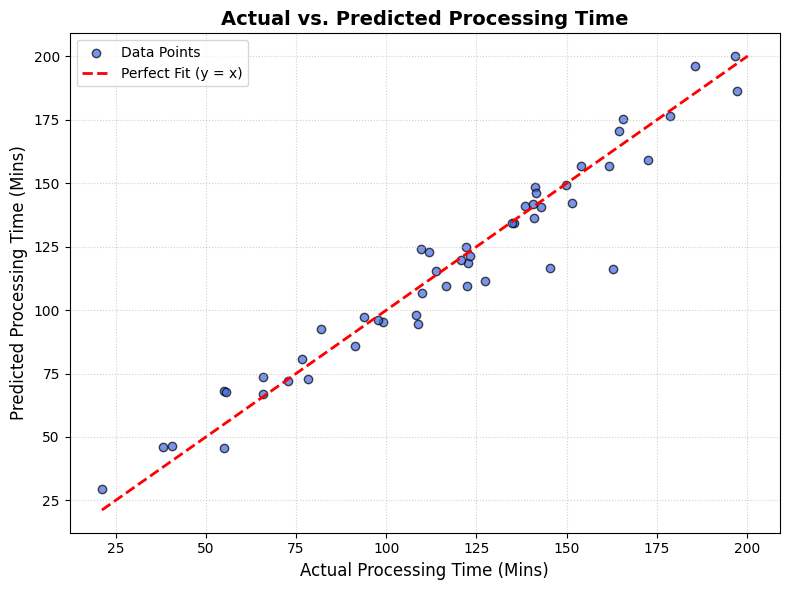

In [26]:
import matplotlib.pyplot as plt

# ==============================================================================
#  VISUALIZE MODEL PERFORMANCE (Actual vs. Predicted Plot)
# ==============================================================================
plt.figure(figsize=(8, 6))

# Scatter plot of Actual y vs Predicted y
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7, edgecolors='k', label='Data Points')

# Draw the ideal reference line (y = x where predictions perfectly match actuals)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')

# Plot Formatting
plt.title('Actual vs. Predicted Processing Time', fontsize=14, fontweight='bold')
plt.xlabel('Actual Processing Time (Mins)', fontsize=12)
plt.ylabel('Predicted Processing Time (Mins)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()